# Face-aware crop vs. centre crop

`face_aware_crop` (in `src/lib/crop.py`) resizes-to-cover then biases the crop toward
Immich-detected face boxes — keeping every face in frame when they fit, falling back to an
area-weighted centroid when they don't, and centre-cropping when there are no faces.

This notebook scans a pool of photos, fetches their face boxes, and picks the cases where
the face-aware crop is **maximally different from a plain centre crop** — those are the ones
where the smart logic earns its keep. For each pick it shows:

1. Original, with face boxes drawn (head-extended boxes in cyan, raw boxes in yellow)
2. Plain centre crop result (what `_crop_center` would do)
3. Face-aware crop result (what production uses)
4. Crop-window overlay on the original (centre = orange, face-aware = green)

Plus one **no-faces** case to confirm the fallback behaves like a plain centre crop.

In [1]:
import sys
sys.path.insert(0, '.')
from _helpers import bootstrap, immich_client, fetch_pool, download_image, silenced, show_grid, CACHE_DIR
bootstrap()

import json
import math
import numpy as np
from PIL import Image, ImageDraw
from waveshare_epd.epd7in3e import EPD_WIDTH, EPD_HEIGHT, _crop_center
from crop import face_aware_crop, HEAD_EXTENSION

POOL_SIZE = 80   # smaller than auto-tune notebook — each photo costs an extra API call for faces
SEED = 7
N_PICKS = 4      # most-divergent picks (plus one no-faces baseline)

In [2]:
client = immich_client()
pool_assets = fetch_pool(client, pool_size=POOL_SIZE, seed=SEED)
print(f'pool size: {len(pool_assets)} landscape photos')

# Cache the face lookups — each is a separate /assets/{id} API call.
face_cache_path = CACHE_DIR / 'faces.json'
CACHE_DIR.mkdir(exist_ok=True)
face_cache = json.loads(face_cache_path.read_text()) if face_cache_path.exists() else {}

fetched_now = 0
for asset in pool_assets:
    if asset['id'] in face_cache:
        continue
    face_cache[asset['id']] = client.get_asset_faces(asset['id'])
    fetched_now += 1
if fetched_now:
    face_cache_path.write_text(json.dumps(face_cache))
print(f'face data: {fetched_now} fetched, {len(pool_assets) - fetched_now} cached')

pool size: 80 landscape photos
face data: 80 fetched, 0 cached


In [3]:
# For each asset, compute centre-crop offset and face-aware-crop offset on the
# resize-to-cover canvas. We re-implement just the offset math here so the comparison
# doesn't depend on actually invoking the crops yet.
def crop_offsets(img_w, img_h, target_w, target_h, faces):
    img_aspect = img_w / img_h
    target_aspect = target_w / target_h
    if img_aspect < target_aspect:
        new_w, new_h = target_w, math.ceil(target_w / img_aspect)
    else:
        new_w, new_h = math.ceil(target_h * img_aspect), target_h

    centre_off = (max(0, (new_w - target_w) // 2), max(0, (new_h - target_h) // 2))
    cx, cy = new_w / 2, new_h / 2
    if faces:
        boxes = []
        for f in faces:
            sx = new_w / (f.get('imageWidth') or img_w)
            sy = new_h / (f.get('imageHeight') or img_h)
            x1 = f['boundingBoxX1'] * sx; y1 = f['boundingBoxY1'] * sy
            x2 = f['boundingBoxX2'] * sx; y2 = f['boundingBoxY2'] * sy
            boxes.append((x1, y1, x2, y2, max(0.0, (x2 - x1) * (y2 - y1))))
        x_lo, x_hi = min(b[0] for b in boxes), max(b[2] for b in boxes)
        if x_hi - x_lo <= target_w:
            cx = (x_lo + x_hi) / 2
        else:
            total = sum(b[4] for b in boxes) or 1.0
            cx = sum((b[0] + b[2]) / 2 * b[4] for b in boxes) / total
        y_lo_ext = min(b[1] - (b[3] - b[1]) * HEAD_EXTENSION for b in boxes)
        y_hi = max(b[3] for b in boxes)
        if y_hi - y_lo_ext <= target_h:
            cy = (y_lo_ext + y_hi) / 2
        else:
            total = sum(b[4] for b in boxes) or 1.0
            cy = sum((b[1] + b[3]) / 2 * b[4] for b in boxes) / total
    face_off = (max(0, min(int(cx - target_w / 2), new_w - target_w)),
                max(0, min(int(cy - target_h / 2), new_h - target_h)))
    return centre_off, face_off, (new_w, new_h), boxes if faces else []

stats = []
for asset in pool_assets:
    exif = asset.get('exifInfo') or {}
    iw, ih = exif.get('exifImageWidth') or 0, exif.get('exifImageHeight') or 0
    if exif.get('orientation') in (6, 8, '6', '8'):
        iw, ih = ih, iw
    if not (iw and ih):
        continue
    faces = face_cache.get(asset['id'], [])
    centre_off, face_off, canvas, boxes = crop_offsets(iw, ih, EPD_WIDTH, EPD_HEIGHT, faces)
    dx = face_off[0] - centre_off[0]
    dy = face_off[1] - centre_off[1]
    stats.append({
        'asset': asset, 'faces': faces, 'boxes': boxes,
        'centre_off': centre_off, 'face_off': face_off, 'canvas': canvas,
        'shift': math.hypot(dx, dy), 'dx': dx, 'dy': dy,
    })

with_faces = [s for s in stats if s['faces']]
no_faces = [s for s in stats if not s['faces']]
print(f'{len(with_faces)} with faces, {len(no_faces)} without')
shifts = np.array([s['shift'] for s in with_faces])
if len(shifts):
    print(f'crop shift (px): min={shifts.min():.0f}  median={np.median(shifts):.0f}  max={shifts.max():.0f}')

80 with faces, 0 without
crop shift (px): min=1  median=45  max=60


In [4]:
with_faces.sort(key=lambda s: s['shift'], reverse=True)
picks = with_faces[:N_PICKS]
if no_faces:
    picks.append(no_faces[0])

print(f"{'name':36s}  {'faces':>5s}  {'dx':>5s} {'dy':>5s}  {'|shift|':>7s}")
for s in picks:
    name = (s['asset'].get('originalFileName') or s['asset']['id'])[:36]
    print(f"{name:36s}  {len(s['faces']):>5d}  {s['dx']:>+5.0f} {s['dy']:>+5.0f}  {s['shift']:>7.0f}")

name                                  faces     dx    dy  |shift|
IMG_6698.JPG                              2     +0   -60       60
IMG_2373.JPG                              2     +0   -60       60
3d91beaa-9136-4488-bc17-c0c333fd79bb      5     +0   -60       60
IMG_2538.JPG                              2     +0   -60       60


Center cropping...
Center cropping...
Center cropping...
Center cropping...


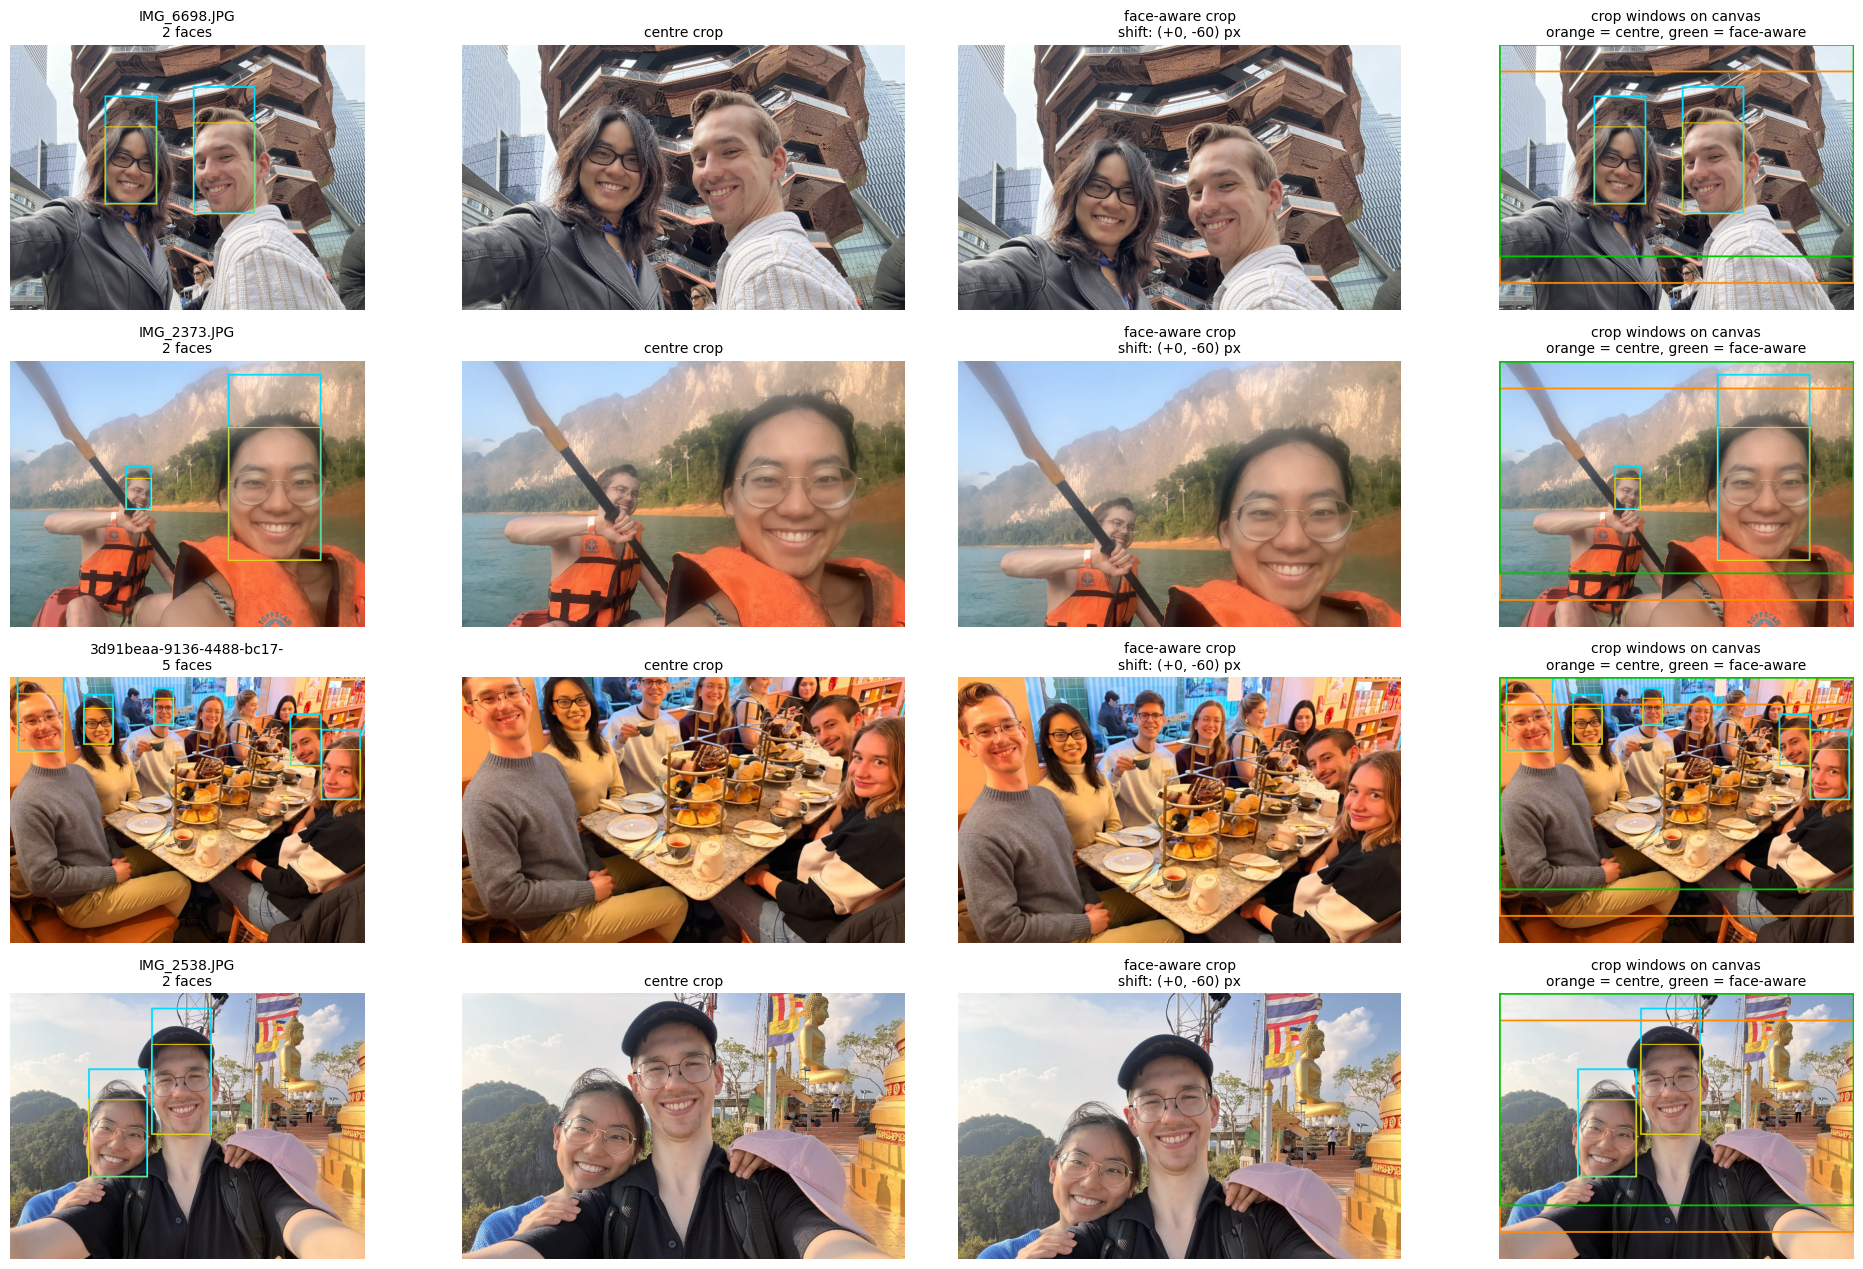

In [5]:
def draw_boxes_on_canvas(image, faces, target=(EPD_WIDTH, EPD_HEIGHT)):
    """Resize-to-cover the image, draw face boxes on it (cyan = head-extended, yellow = raw)."""
    iw, ih = image.size
    img_aspect = iw / ih
    target_aspect = target[0] / target[1]
    if img_aspect < target_aspect:
        new_w, new_h = target[0], math.ceil(target[0] / img_aspect)
    else:
        new_w, new_h = math.ceil(target[1] * img_aspect), target[1]
    canvas = image.resize((new_w, new_h), Image.LANCZOS).copy()
    draw = ImageDraw.Draw(canvas)
    for f in faces:
        sx = new_w / (f.get('imageWidth') or iw)
        sy = new_h / (f.get('imageHeight') or ih)
        x1, y1 = f['boundingBoxX1'] * sx, f['boundingBoxY1'] * sy
        x2, y2 = f['boundingBoxX2'] * sx, f['boundingBoxY2'] * sy
        head_y1 = y1 - (y2 - y1) * HEAD_EXTENSION
        draw.rectangle([x1, head_y1, x2, y2], outline=(0, 220, 255), width=4)
        draw.rectangle([x1, y1, x2, y2], outline=(255, 220, 0), width=2)
    return canvas, (new_w, new_h)

def draw_crop_windows(canvas, centre_off, face_off, target=(EPD_WIDTH, EPD_HEIGHT)):
    out = canvas.copy()
    draw = ImageDraw.Draw(out)
    cx, cy = centre_off
    fx, fy = face_off
    draw.rectangle([cx, cy, cx + target[0], cy + target[1]], outline=(255, 140, 0), width=4)
    draw.rectangle([fx, fy, fx + target[0], fy + target[1]], outline=(0, 200, 0), width=4)
    return out

rows, titles = [], []
for s in picks:
    img = download_image(client, s['asset'])
    canvas, _ = draw_boxes_on_canvas(img, s['faces'])
    windowed = draw_crop_windows(canvas, s['centre_off'], s['face_off'])
    centre = _crop_center(img, EPD_WIDTH, EPD_HEIGHT)
    smart = face_aware_crop(img, EPD_WIDTH, EPD_HEIGHT, s['faces'])
    name = (s['asset'].get('originalFileName') or s['asset']['id'])[:24]
    rows.append([canvas, centre, smart, windowed])
    titles.append([
        f'{name}\n{len(s["faces"])} face{"" if len(s["faces"]) == 1 else "s"}',
        'centre crop',
        f'face-aware crop\nshift: ({s["dx"]:+.0f}, {s["dy"]:+.0f}) px',
        'crop windows on canvas\norange = centre, green = face-aware',
    ])

with silenced():
    show_grid(rows, titles, figsize_scale=(5.0, 3.2));

## Reading the comparison

- **Cyan boxes** are the head-extended face regions the algorithm tries to keep in frame —
  the extension (`HEAD_EXTENSION`) accounts for the fact that Immich's boxes end at the hairline.
- **Yellow boxes** are the raw bounding boxes Immich reported.
- The biggest visual win is when faces are clustered to one side, near a horizontal or vertical
  edge: centre crop slices through them, face-aware crop slides the window to keep them whole.
- When face span exceeds the crop dimension on an axis, the algorithm falls back to an
  area-weighted centroid — that's intentional: it biases toward the foreground (largest) face
  rather than splitting the crop badly between far-apart subjects.
- The no-faces row should look identical between centre and face-aware crops — that confirms
  the no-face fallback path.